## 4. Naive Bayes 

### 4.1 Packages Importeren

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    f1_score, roc_auc_score, classification_report, accuracy_score
)
from scipy import stats

from preprocessing import(
    my_preprocessor,
    my_tokenizer,
)
from helpfuncties import load_dataset

### 4.2 Dataset inladen 

In [2]:
df = load_dataset()
y = df['Product']
X = df['Omschrijving']

### 4.3 Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)

### 4.5 Pipeline + Hyperparameter Tuning

#### 4.5.1 Naive Bayes Pipeline

In [4]:
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        preprocessor=my_preprocessor,
        tokenizer=my_tokenizer,
        analyzer='word',
        ngram_range=(1,1),
        token_pattern=None,
        binary=True,
        min_df=2,
        max_df=0.95
    )),
    ('model', MultinomialNB())
])

#### 4.5.2 RandomizedSearchCV

In [5]:
random_params = {
    # Modelparameters
    "model__alpha": stats.loguniform(1e-4, 50),  
    "model__fit_prior": [True, False],

    # TF-IDF parameters
    "tfidf__ngram_range": [(1,1), (1,2), (1,3)],
    "tfidf__min_df": [1, 2, 3, 5, 10],
    "tfidf__max_df": [0.5, 0.65, 0.75, 0.85, 1.0],
    "tfidf__binary": [True, False],
    "tfidf__use_idf": [True, False],   # in NB soms goed, soms slecht
    "tfidf__norm": ["l1", "l2"],       # belangrijk voor NB!
}

random_search = RandomizedSearchCV(
    nb_pipeline,
    param_distributions=random_params,
    n_iter=80,
    scoring="f1_macro",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
best = random_search.best_params_

print("\nBeste parameters Random Search")
print(best)

Fitting 3 folds for each of 80 candidates, totalling 240 fits

Beste parameters Random Search
{'model__alpha': np.float64(0.016929443114170727), 'model__fit_prior': False, 'tfidf__binary': False, 'tfidf__max_df': 0.85, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l2', 'tfidf__use_idf': False}


#### 4.5.3 GridSearchCV

In [6]:
grid_params_nb = {
    "model__alpha": [
        best["model__alpha"] * 0.5,
        best["model__alpha"],
        best["model__alpha"] * 2
    ],
    "model__fit_prior": [best["model__fit_prior"]],

    "tfidf__min_df": [
        max(1, best["tfidf__min_df"] - 1),
        best["tfidf__min_df"],
        best["tfidf__min_df"] + 1
    ],
    "tfidf__max_df": [
        max(0.1, best["tfidf__max_df"] - 0.1),
        best["tfidf__max_df"],
        min(1.0, best["tfidf__max_df"] + 0.1)
    ],
    "tfidf__ngram_range": [best["tfidf__ngram_range"]],
    "tfidf__binary": [best["tfidf__binary"]],
    "tfidf__use_idf": [best["tfidf__use_idf"]],
    "tfidf__norm": [best["tfidf__norm"]],
}

In [7]:
grid = GridSearchCV(
    nb_pipeline,
    param_grid=grid_params_nb,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)
nb_pipeline_best = grid.best_estimator_

print("\nBeste Parameters GridSearch")
print(grid.best_params_)

Fitting 3 folds for each of 27 candidates, totalling 81 fits

Beste Parameters GridSearch
{'model__alpha': np.float64(0.033858886228341455), 'model__fit_prior': False, 'tfidf__binary': False, 'tfidf__max_df': 0.75, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l2', 'tfidf__use_idf': False}


### 4.6 Evaluatie modelprestaties

#### 4.6.1 Voorspellingen

In [9]:
y_pred_nb = nb_pipeline_best.predict(X_test)
y_proba_nb = nb_pipeline_best.predict_proba(X_test)

#### 4.6.2 Totale metrics

In [10]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

print(f'Accuracy Naive Bayes: {accuracy_nb:.3f}')
print(f"F1 Naive Bayes: {f1_nb:.3f}")

Accuracy Naive Bayes: 0.833
F1 Naive Bayes: 0.832


#### 4.6.3 Classification Report

In [11]:
print(classification_report(y_test, y_pred_nb))

                    precision    recall  f1-score   support

      Bankrekening       0.84      0.84      0.84       447
Consumentenkrediet       0.69      0.56      0.62       284
        Creditcard       0.78      0.81      0.80       565
         Hypotheek       0.91      0.94      0.92       994
           Incasso       0.87      0.80      0.84      1229
Kredietregistratie       0.78      0.85      0.81       948

          accuracy                           0.83      4467
         macro avg       0.81      0.80      0.80      4467
      weighted avg       0.83      0.83      0.83      4467



#### 4.6.4 Confusion Matrix Naive Bayes

[[374   6  37  14   7   9]
 [  8 159  17  29  40  31]
 [ 35   5 458   6  29  32]
 [ 15   7   8 936   5  23]
 [  9  32  30  35 988 135]
 [  4  21  36  12  67 808]]


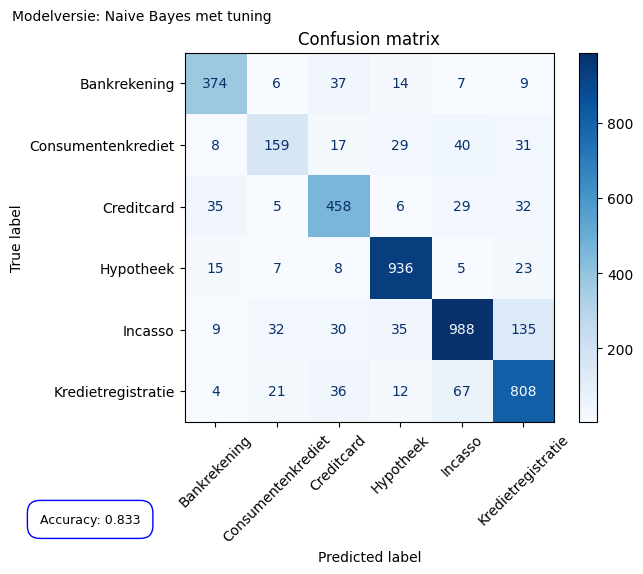

In [12]:
cm = confusion_matrix(y_test, y_pred_nb)
print(cm)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    cmap='Blues'
)
plt.xticks(rotation=45)
plt.title('Confusion matrix')
plt.suptitle("Modelversie: Naive Bayes met tuning", fontsize=10, x=0.1, y=0.97) # ! naam aanpassen per modelversie
plt.figtext(0.02, -0.1, f"Accuracy: {accuracy_nb:.3f}", ha='center', fontsize=9, color='black', bbox=dict(facecolor='none', edgecolor='blue', boxstyle='round,pad=1'))
plt.savefig("afbeeldingen/confusion_matrix_naive_bayes_met_tuning.png", dpi=300, bbox_inches='tight') # ! naam aanpassen per modelversie
plt.show()

#### 4.6.5 AUC-score (multiclass)

In [13]:
auc_nb = roc_auc_score(y_test, y_proba_nb, multi_class='ovr')
print(f"AUC: {auc_nb:.3f}")

AUC: 0.963
